# Sequence Labeling Model Results Visualization

In [1]:
import os
import json
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tabulate import tabulate

In [2]:
def load_results(results_base_path="tnqeet/dotting_models/sequence_labeling/evaluation_results", dataset_type="val_dataset"):
    results_path = os.path.join(results_base_path, dataset_type)
    data = []
    
    for result_file in glob.glob(os.path.join(results_path, "*.json")):
        filename = os.path.basename(result_file)
        parts = filename.replace('_results.json', '').split('_')
        model_name = parts[0]
        n_layers = int(parts[2])
        
        with open(result_file, 'r', encoding='utf-8') as f:
            results = json.load(f)
        
        if not results:
            continue
        
        avg_wer = sum(r["wer"] for r in results) / len(results)
        avg_cer = sum(r["cer"] for r in results) / len(results)
        avg_doer = sum(r["doer"] for r in results) / len(results)
        
        def parse_time(time_str):
            try:
                if isinstance(time_str, str) and ":" in time_str:
                    parts = time_str.split(":")
                    hours, minutes = int(parts[0]), int(parts[1])
                    seconds = float(parts[2])
                    return hours * 3600 + minutes * 60 + seconds
                return float(time_str)
            except:
                return 0.0
        
        times = [parse_time(r["dotting_time"]) for r in results]
        avg_time = sum(times) / len(times)
        
        data.append({
            "Model": model_name,
            "Layers": n_layers,
            "WER": f"{avg_wer:.4f}",
            "CER": f"{avg_cer:.4f}",
            "DOER": f"{avg_doer:.4f}",
            "Inference Time (s)": f"{avg_time:.4f}"
        })
    
    df = pd.DataFrame(data)
    if not df.empty:
        df = df.sort_values('Layers')
    return df

## Validation val Results

In [4]:
val_df = load_results(dataset_type="val_dataset")
print(tabulate(val_df, headers='keys', tablefmt='grid', showindex=False))

+---------+----------+--------+--------+--------+----------------------+
| Model   |   Layers |    WER |    CER |   DOER |   Inference Time (s) |
+=========+==========+========+========+========+======================+
| LSTM    |        1 | 0.0827 | 0.0173 | 0.0205 |               0.0219 |
+---------+----------+--------+--------+--------+----------------------+
| LSTM    |        2 | 0.0526 | 0.0111 | 0.0131 |               0.0308 |
+---------+----------+--------+--------+--------+----------------------+
| LSTM    |        3 | 0.049  | 0.0104 | 0.0124 |               0.0462 |
+---------+----------+--------+--------+--------+----------------------+
| LSTM    |        4 | 0.0427 | 0.0088 | 0.0104 |               0.06   |
+---------+----------+--------+--------+--------+----------------------+
| LSTM    |        5 | 0.0449 | 0.0094 | 0.0111 |               0.0762 |
+---------+----------+--------+--------+--------+----------------------+


In [5]:
def plot_results(df, dataset_name="val_dataset", figsize=(10, 6)):
    if df.empty:
        print("No data to plot")
        return
    
    df_plot = df.copy()
    df_plot['WER_numeric'] = df_plot['WER'].astype(float)
    df_plot['CER_numeric'] = df_plot['CER'].astype(float)
    df_plot['DOER_numeric'] = df_plot['DOER'].astype(float)
    
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=figsize)
    
    x = df_plot['Layers']
    width = 0.25
    x_pos = np.arange(len(x))
    
    ax.bar(x_pos - width, df_plot['WER_numeric'], width, label='WER', 
           color='#e74c3c', alpha=0.8, edgecolor='white', linewidth=1.5)
    ax.bar(x_pos, df_plot['CER_numeric'], width, label='CER', 
           color='#3498db', alpha=0.8, edgecolor='white', linewidth=1.5)
    ax.bar(x_pos + width, df_plot['DOER_numeric'], width, label='DOER', 
           color='#2ecc71', alpha=0.8, edgecolor='white', linewidth=1.5)
    
    ax.set_xlabel('Number of LSTM Layers', fontsize=12, fontweight='bold')
    ax.set_ylabel('Error Rate', fontsize=12, fontweight='bold')
    ax.set_title(f'Sequence Labeling Performance - {dataset_name.replace("_", " ").title()}', 
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x)
    ax.legend(fontsize=10, loc='upper right')
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_axisbelow(True)
    
    plt.tight_layout()
    
    os.makedirs('tnqeet/dotting_models/sequence_labeling/visualization_figures', exist_ok=True)
    output_path = f'tnqeet/dotting_models/sequence_labeling/visualization_figures/{dataset_name}_results.pdf'
    plt.savefig(output_path, dpi=300, bbox_inches='tight', format='pdf')
    print(f"Figure saved to: {output_path}")
    
    plt.show()

Figure saved to: tnqeet/dotting_models/sequence_labeling/visualization_figures/val_dataset_results.pdf


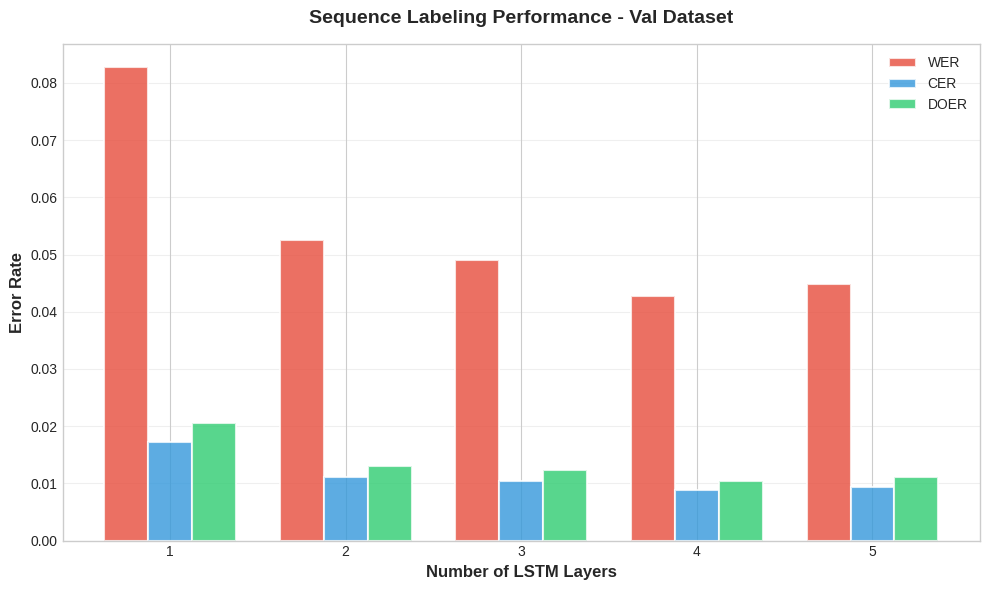

In [6]:
plot_results(val_df, dataset_name="val_dataset")

## Test Results

In [7]:
test_df = load_results(dataset_type="test_dataset")
print(tabulate(test_df, headers='keys', tablefmt='grid', showindex=False))

+---------+----------+--------+--------+--------+----------------------+
| Model   |   Layers |    WER |    CER |   DOER |   Inference Time (s) |
+=========+==========+========+========+========+======================+
| LSTM    |        1 | 0.1283 | 0.0263 | 0.0306 |               0.0335 |
+---------+----------+--------+--------+--------+----------------------+
| LSTM    |        2 | 0.0989 | 0.0201 | 0.0233 |               0.0614 |
+---------+----------+--------+--------+--------+----------------------+
| LSTM    |        3 | 0.0961 | 0.0197 | 0.0228 |               0.0929 |
+---------+----------+--------+--------+--------+----------------------+
| LSTM    |        4 | 0.0898 | 0.0183 | 0.0212 |               0.1208 |
+---------+----------+--------+--------+--------+----------------------+
| LSTM    |        5 | 0.0926 | 0.0189 | 0.0218 |               0.1536 |
+---------+----------+--------+--------+--------+----------------------+


Figure saved to: tnqeet/dotting_models/sequence_labeling/visualization_figures/test_dataset_results.pdf


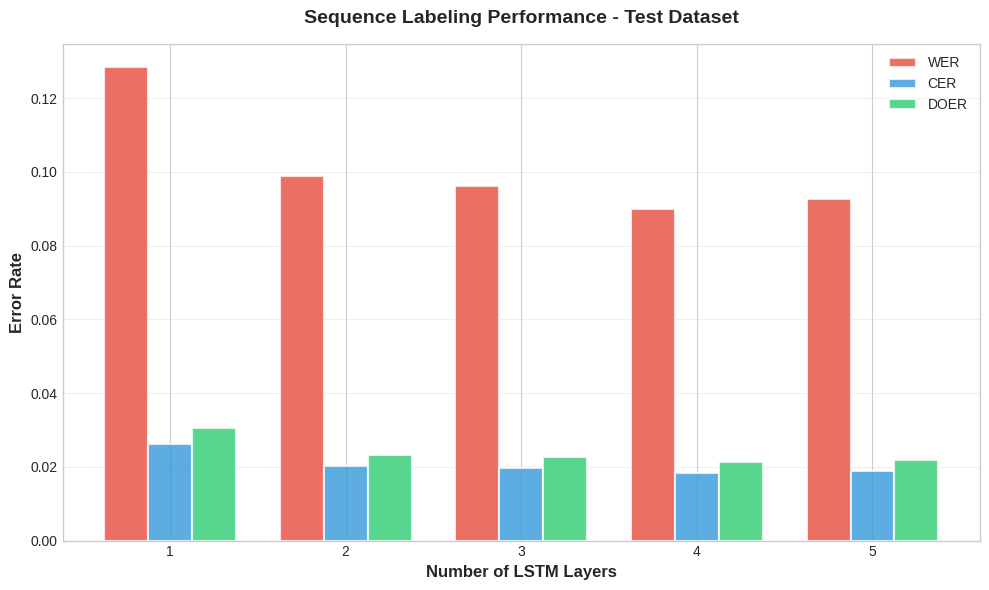

In [7]:
plot_results(test_df, dataset_name="test_dataset")